## Linear Regression Model

In [ ]:
# step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# step 2: load the dataset
data=pd.read_csv("linear_regression_datasest.csv")

In [3]:
df.head()

,Feature_1,Feature_2,Target
0,18.727006,26.661964,75.032045
1,47.535715,58.771085,186.095787
2,36.599697,88.565125,200.512604
3,29.932924,75.900240,174.586253
4,7.800932,82.590503,132.746780


In [7]:
# step 3: Data Preprocessing
data.isnull().sum()

Feature_1    0
Feature_2    0
Target       0
dtype: int64

In [8]:
# check statistics of the dataset
data.describe()

,Feature_1,Feature_2,Target
count,1000.000000,1000.000000,1000.000000
mean,24.512828,55.631557,133.169216
std,14.606868,26.297090,49.845584
min,0.231601,10.289644,11.866554
25%,11.798663,31.696684,97.734249
50%,24.840369,56.686052,134.027666
75%,37.215979,78.441855,169.051039
max,49.985884,99.947235,255.915972


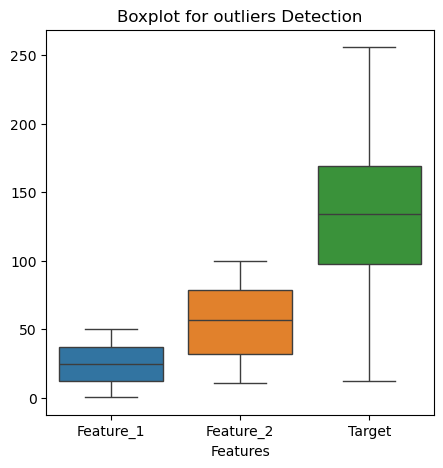

In [11]:
# check for the outliers
plt.figure(figsize=(5,5))
sns.boxplot(data=data)
plt.title("Boxplot for outliers Detection")
plt.xlabel("Features")
plt.show()

<Axes: xlabel='Feature_2', ylabel='Target'>

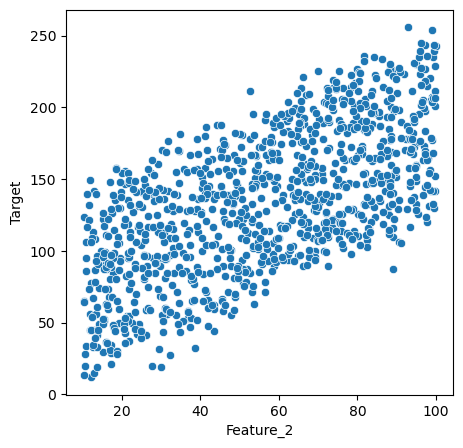

In [13]:
#step 4: EDA
plt.figure(figsize=(5,5))
sns.scatterplot(x='Feature_2',y='Target',data=data)



In [ ]:
# step 5: Divide the dataset into features and target variable
x=data.drop("Target",axis=1)   #axis=1 or true means column
y=data["Target"]

In [19]:
x.head()
x.shape,y.shape

((1000, 2), (1000,))

In [23]:
# step 6: 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



In [28]:
# step 7: Train the Linear Regression model
# 1.import the Linear Regression model
from sklearn.linear_model import LinearRegression

#load the model
model=LinearRegression()
 
# 2. Train the model using the training data
model.fit(x_train,y_train)

#predict  the target varaible for the test set
y_pred=model.predict(x_test)



In [27]:
y_pred

array([165.30267131, 140.22983517, 164.04239661, 126.21150297,
       148.06003385, 157.13456198,  96.49042232, 127.42460859,
       103.56485267, 173.63283429, 204.43353053, 154.98883852,
       126.66383417,  99.60925032,  85.27976999, 112.00908159,
       195.0863718 , 111.89923294, 146.91654313,  54.70557701,
       181.93800542, 166.0788785 ,  38.59772984,  84.22598987,
       131.5812335 , 147.16137299, 201.09546041, 181.62622057,
       121.58627136, 145.61143287, 133.76687475, 202.57072389,
        49.55261908, 233.58057523, 134.14412894, 208.89248344,
       104.42584516, 202.73148621,  20.69872644, 125.25207962,
       140.44170622, 106.1499688 ,  79.00495519,  52.9144471 ,
       103.6559509 , 204.68840071, 155.74865985,  86.60949566,
        99.59297082,  98.72861809, 144.51276844, 105.55085022,
       226.97370656, 143.97652222, 167.42696409,  97.01531861,
       122.87379004,  43.23029449, 104.38492849, 139.69784544,
       131.45776658, 199.37146995, 106.63455852, 144.44

In [29]:
# difference between actual and predicted values make dataframe
results=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})

In [30]:
#find the loss function value using mean squared error
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)


Mean Squared Error: 100.35222719050985


In [31]:
#find the model evaluation using R-squared score
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)
print("R-squared Score:",r2)


R-squared Score: 0.957500280399683


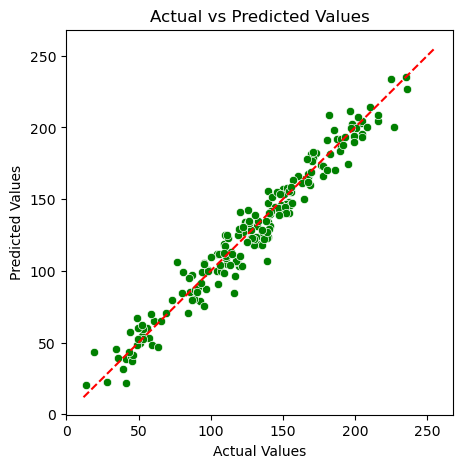

In [32]:

# display best fit line for the test data
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Add a reference line
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()